In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
data=pd.read_csv("netflix_titles.csv")
df=data.copy()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [55]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [56]:
df.shape

(8807, 12)

In [57]:
df.info() ## boş deger var mı
## df.info() çıktısına göre toplam satır sayısı 8807'dir.
## Bir sütunda Non-Null Count değeri 8807 ise, o sütunda boş (NaN) değer yoktur.
## show_id, type ve title sütunlarının non-null sayısı 8807 olduğu için
## bu sütunlarda eksik veri bulunmamaktadır.
## 8807'den küçük non-null değere sahip sütunlarda ise
## (8807 - non_null_count) kadar boş değer olduğu anlaşılır.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [58]:
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

In [59]:
df["rating"].unique() ## rating= hangi yaş içerik üreticileri var kanallar?

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [60]:
df["country"].unique() ## hangi ülkeler

array(['United States', 'South Africa', nan, 'India',
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'Mexico', 'Turkey',
       'Australia', 'United States, India, France', 'Finland',
       'China, Canada, United States',
       'South Africa, United States, Japan', 'Nigeria', 'Japan',
       'Spain, United States', 'France', 'Belgium',
       'United Kingdom, United States', 'United States, United Kingdom',
       'France, United States', 'South Korea', 'Spain',
       'United States, Singapore', 'United Kingdom, Australia, France',
       'United Kingdom, Australia, France, United States',
       'United States, Canada', 'Germany, United States',
       'South Africa, United States', 'United States, Mexico',
       'United States, Italy, France, Japan',
       'United States, Italy, Romania, United Kingdom',
       'Australia, United States', 'Argentina, Venezuela',
       'United States, United Kin

In [61]:
df['country'].isnull().sum() ##country sütununda kaç tane BOŞ (NaN) değer olduğunu sayar.

831

In [62]:
df["date_added"].isnull().sum()

10

In [63]:
df['country'].value_counts() 
## country sütunundaki her farklı değerin kaç kez geçtiğini gösterir.
## Bu sayede hangi ülke / ülke kombinasyonlarının baskın olduğu görülür.
## unique() ile birlikte kullanıldığında,
## hatalı, eksik veya beklenmeyen değerler (virgüllü, boşluklu, NaN vb.)
## daha hızlı ve kolay şekilde tespit edilebilir.
## Özellikle çoklu ülke içeren kayıtların varlığı bu aşamada fark edilir.

country
United States                             2818
India                                      972
United Kingdom                             419
Japan                                      245
South Korea                                199
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 748, dtype: int64

In [64]:
df.describe().T 
## bu çıktı bize şunu gösterdi bu datasette çoğunluk kategorik değişken tek sayısal değişken var 
## o da release_year yani kategorik değişken ağırlıklı bir dataset

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


In [65]:
df.describe(include="object").T ## bu kategorik değişkenleri sırala demek 
## count = kaç dolu
## unique = kaç farklı değer 
## top = en sık değer
## freq= kaç kez geçti 

,count,unique,top,freq
show_id,8807,8807,s1,1
type,8807,2,Movie,6131
title,8807,8807,Dick Johnson Is Dead,1
director,6173,4528,Rajiv Chilaka,19
cast,7982,7692,David Attenborough,19
country,7976,748,United States,2818
date_added,8797,1767,"January 1, 2020",109
rating,8803,17,TV-MA,3207
duration,8804,220,1 Season,1793
listed_in,8807,514,"Dramas, International Movies",362


In [66]:
## type sütunu:
## - type değişkeni kategoriktir.
## - Veri setinde 2 adet kategori bulunmaktadır: Movie ve TV Show.
## - En sık görülen içerik türü Movie’dir (6131 adet).
## - Netflix içeriklerinin büyük çoğunluğu filmlerden oluşmaktadır.

## country sütunu:
## - country değişkeni içeriklerin üretildiği ülkeleri göstermektedir.
## - En sık görülen ülke United States’tir.
## - Bu sonuç, ülke kombinasyonları ayrıştırılmadan elde edilmiştir.
## - Gerçek ülke bazlı analiz için country sütununun bölünmesi (split/explode) gerekmektedir.

## rating sütunu:
## - rating değişkeni içeriklerin yaş ve içerik uygunluk derecelerini ifade etmektedir.
## - Veri setinde 17 farklı rating kategorisi bulunmaktadır.
## - En sık görülen rating TV-MA’dır (18+ içerik).
## - Netflix içeriklerinin büyük bir bölümü yetişkinlere yönelik içeriklerden oluşmaktadır.

In [67]:
df['release_year'].value_counts().sort_index()
## value_counts() yılları frekansa göre sıralar. Yani  en çok hangi yılda olduysa o yıl en yukarıda olur.
## sort_index() ise yılları kronolojik (küçükten büyüğe) sıralamak için kullanılır. Burda da yılları düzenleriz.
## Zaman analizi ve çizgi grafikleri için gereklidir.

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

In [68]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [69]:
df["rating"].value_counts() ##kısaca value_count() Bu sütunda hangi değerden KAÇ TANE var?

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

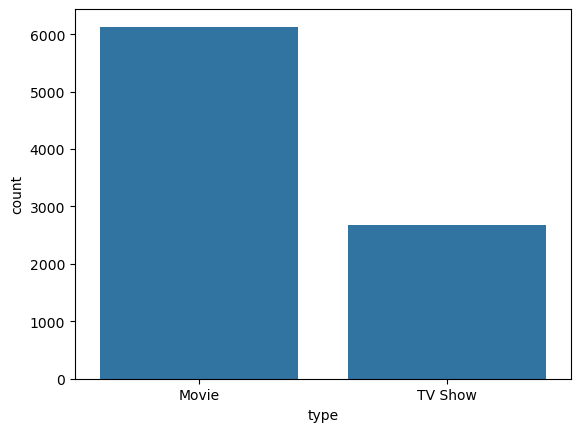

In [70]:
sns.countplot(x='type', data=df);
## Bu grafik bir countplot’tur (sayma grafiği).
## type değişkenindeki her kategorinin kaç kez geçtiğini gösterir.
## Grafikten, Netflix veri setinde film (Movie) sayısının dizi (TV Show) sayısından
## daha fazla olduğu görülmektedir.

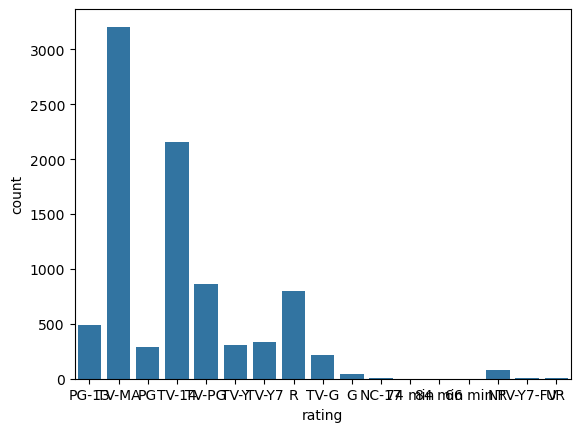

In [71]:
sns.countplot(x="rating", data=df);
## rating çok sıkıştı y eksenine koyup yatay bakmayı deneylim

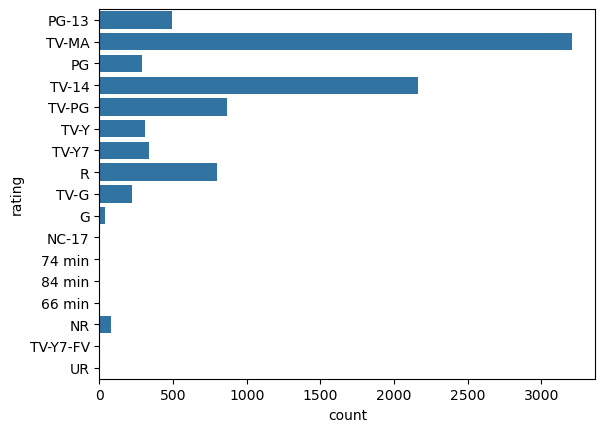

In [72]:
sns.countplot(y="rating", data=df);
## rating değişkeninde kategori sayısı fazla olduğu için
## görsel okunabilirliği artırmak amacıyla yatay countplot tercih edilmiştir.
## Grafik, Netflix içeriklerinde en yaygın yaş sınıflandırmasının
## TV-MA olduğunu göstermektedir.

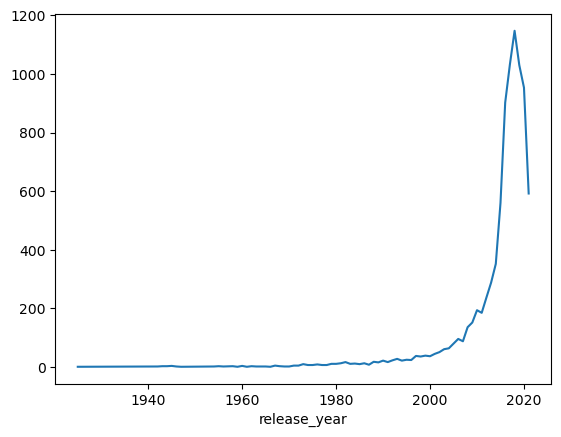

In [73]:
df["release_year"].value_counts().sort_index().plot();
## Bu grafik, Netflix’e eklenen içeriklerin yıllara göre dağılımını göstermektedir.
## Özellikle 2010 sonrası dönemde içerik sayısında hızlı bir artış olduğu,
## 2020 yılına yaklaşırken bu artışın belirginleştiği görülmektedir.
## plot() en çok ZAMAN ve TREND analizinde kullanılır.

In [74]:
## farkındaysan bir sns bir df kullandık sebebi aşağıda df yerine sns ile kullanırmıydık evet ama daha fazla kod yazardık.
## Kategorik değişkenlerin dağılımı için Seaborn kullanılmıştır.
## Zaman serisi analizinde ise value_counts ve sort_index işlemleri
## sonucunda elde edilen Series doğrudan Pandas plot fonksiyonu ile
## görselleştirilmiştir.
## şimdi datasete sormamız gereken soru, evet yıllar içerisinde içerik artmış ama bu artış daha çok moviden mi gelmiş filmden mi?

In [87]:
movie_df = df[df["type"] == "Movie"]
tv_df = df[df["type"] == "TV Show"]

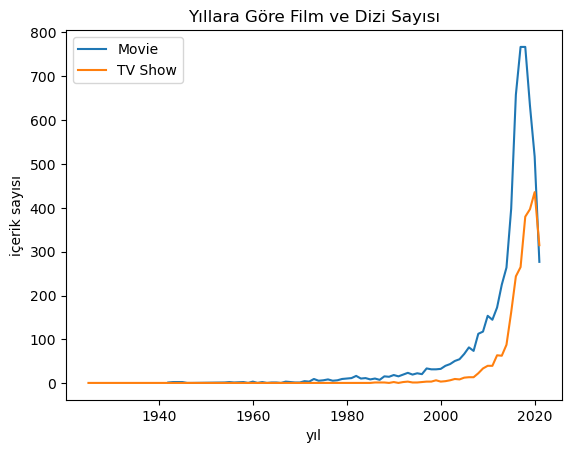

In [88]:
import matplotlib.pyplot as plt
## Matplotlib’i, grafiğin detaylarını (başlık, eksen, legend, boyut) kontrol etmek için kullandık.
## İçerik türleri arasında karşılaştırma yapabilmek amacıyla veri seti filtrelenmiştir.
movie_df["release_year"].value_counts().sort_index().plot(label="Movie"); ## grafikte iki çizgi var label bu çizginiin hangisi olduğunu söyer.
tv_df["release_year"].value_counts().sort_index().plot(label="TV Show");
plt.title("Yıllara Göre Film ve Dizi Sayısı")
plt.xlabel("yıl")
plt.ylabel("içerik sayısı")
plt.legend(); ## grafikteki açıklama kutusu (renk – isim eşleştirmesi) olmazzsa kfa karışıklığı yaşanır hangisi hangisi diye

In [89]:
## GELELİM YORUMA
## İçerik türleri arasındaki farkları inceleyebilmek amacıyla veri seti
## Movie ve TV Show olmak üzere iki gruba ayrılmıştır.
## Yıllara göre oluşturulan çizgi grafiği, içerik sayısındaki artışın
## her iki türde de gerçekleştiğini göstermektedir.
## Ancak film içeriklerinin sayısının, dizilere kıyasla daha yüksek olduğu
## ve artış hızının filmlerde daha belirgin olduğu gözlemlenmiştir.

In [90]:
## Sadece country değişkenini temizleyecğiz temizlemeyi bilmediğim için AI yardımı alıcam.
country_df = df.dropna(subset=['country']).copy()
country_df['country'] = country_df['country'].str.split(',')
country_df = country_df.explode('country')
country_df['country'] = country_df['country'].str.strip()

In [91]:
## temizledikten sonra bi sayalım durum ne bakalım.
country_counts = country_df['country'].value_counts()
country_counts.head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

In [92]:
## Country değişkeni temizlendikten sonra yapılan sayım sonucunda,
## Netflix içeriklerinin büyük bir bölümünün Amerika Birleşik Devletleri
## kaynaklı olduğu görülmüştür.
## ABD’yi sırasıyla Hindistan ve Birleşik Krallık takip etmektedir.
## Bu durum, Netflix’in hem küresel hem de yerel pazarlara yönelik
## içerik üretim stratejisini benimsediğini göstermektedir.

In [93]:
top10_countries = country_df['country'].value_counts().head(10)
top10_countries

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

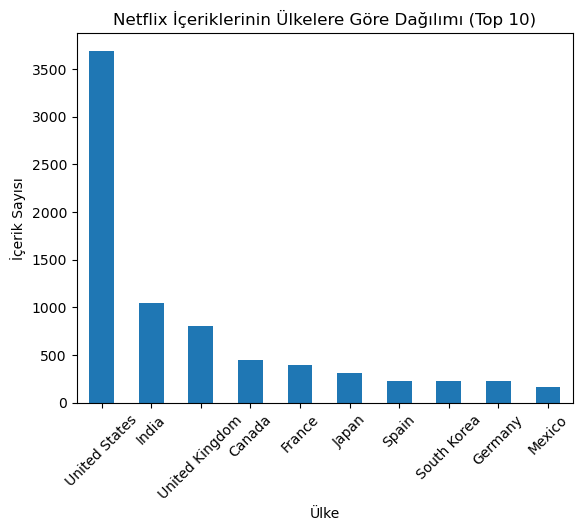

In [94]:
top10_countries.plot(kind='bar') #### Kategorik verilerin karşılaştırılması amacıyla bar chart kullanılmıştır. Hem sayısal veri hem kategorik veri var.
## en uygun bar chart garfik türüdür.
plt.title("Netflix İçeriklerinin Ülkelere Göre Dağılımı (Top 10)")
plt.xlabel("Ülke")
plt.ylabel("İçerik Sayısı")
plt.xticks(rotation=45); ## x eksenine yazılan ülke isimlerini 45 derece eğik yazar.

In [95]:
## Netflix içeriklerinin ülkelere göre dağılımı incelendiğinde, içerik üretiminin büyük ölçüde Amerika Birleşik Devletleri’nde yoğunlaştığı görülmektedir. 
## ABD’yi Hindistan ve Birleşik Krallık takip etmektedir.
## Bu durum, Netflix’in küresel içerik stratejisinde belirli ülkeleri merkez olarak konumlandırdığını göstermektedir.

In [96]:
country_year_counts = (
    country_df
    .groupby(['country', 'release_year'])
    .size()
    .reset_index(name='count')
)

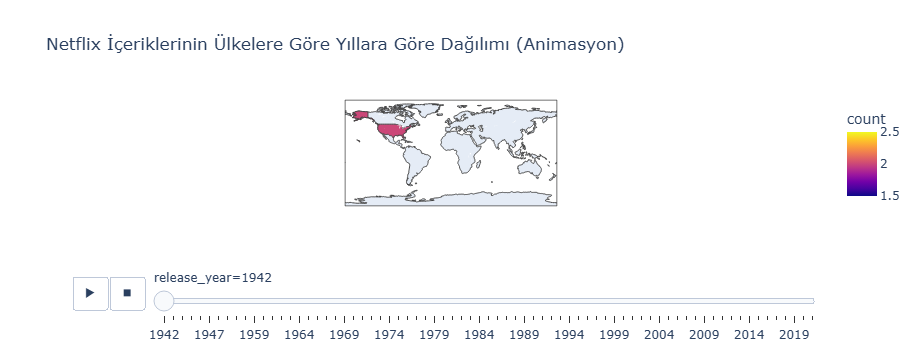

In [97]:
import plotly.express as px ## harita için plotly kullanıyoruz
fig = px.choropleth(
    country_year_counts.sort_values('release_year'),
    locations="country",
    locationmode="country names",
    color="count",
    animation_frame="release_year",
    hover_name="country",
    hover_data={"count": True},
    title="Netflix İçeriklerinin Ülkelere Göre Yıllara Göre Dağılımı (Animasyon)"
)

fig.show() ## Haritayı ekrana çizdirir oynat tuşu burda çalışır.


In [ ]:
## bu kodu ayrıyca tek tek açıklayalım
## 